# 🏡 Machine Learning for Design Inspiration Recommendation System

**Nhóm 13 – Machine Learning for Design | ĐHCN – ĐHQGHN**

---

### Pipeline tổng quan
```
User Query (text)
  → [1] Cài đặt & Import
  → [2] Load & Khám phá dữ liệu (EDA)
  → [3] Tiền xử lý (giữ nguyên từ nhóm)
  → [4] Train Style Classifier (RandomForest)
  → [5] Train Material Classifier (RandomForest)
  → [6] Train Color Regressor (MultiOutput RF)
  → [7] NLP Embedding (SentenceTransformer)
  → [8] Cosine Similarity Search
  → [9] Demo gợi ý đầy đủ
  → [10] Visualizations & Dashboard
  → [11] Lưu models
```

## 1. Cài đặt thư viện

In [1]:
# Cài thư viện cần thiết (bỏ comment nếu chạy lần đầu)
# !pip install sentence-transformers plotly scikit-learn joblib pandas numpy

import os, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, r2_score, classification_report
from sklearn.metrics.pairwise import cosine_similarity

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from IPython.display import display, HTML

warnings.filterwarnings("ignore")
print("✓ Import hoàn tất")

✓ Import hoàn tất


## 2. Load & Khám phá dữ liệu (EDA)

In [2]:
DATA_PATH = "data/dataset_cleaned_ready.csv"
df = pd.read_csv(DATA_PATH)

print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head(5)

Shape: (1000, 19)
Columns: ['Image_id', 'material_image_id', 'style_tags_boho', 'style_tags_industrial', 'style_tags_minimalist', 'style_tags_scandinavian', 'material_type_fabric', 'material_type_glass', 'material_type_leather', 'material_type_marble', 'material_type_metal', 'material_type_stone', 'material_type_tile', 'material_type_wood', 'clean_design_description', 'user_preference', 'color1', 'color2', 'color3']


,Image_id,material_image_id,style_tags_boho,style_tags_industrial,style_tags_minimalist,style_tags_scandinavian,material_type_fabric,material_type_glass,material_type_leather,material_type_marble,material_type_metal,material_type_stone,material_type_tile,material_type_wood,clean_design_description,user_preference,color1,color2,color3
0,1,1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,a modern loft with exposed brick and steel fin...,"wants a modern, urban atmosphere",#3020D7,#02A235,#DE15E9
1,2,2,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,a simple clean space with neutral colors and o...,prefers simplicity and neutral palettes,#AE05EA,#341643,#2CA865
2,3,3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,a warehouse inspired kitchen featuring raw mat...,"wants a modern, urban atmosphere",#7D8FE0,#7B30A7,#83CE64
3,4,4,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,bohemian style living room full of plants and ...,likes vibrant colors and handmade decor,#CD1C51,#897AD6,#C05A75
4,5,5,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,a bedroom with white walls simple furniture an...,prefers simplicity and neutral palettes,#760885,#9D13F1,#4D0B0E


In [3]:
# ── Định nghĩa cột style / material ─────────────────────────────────────────
STYLE_COLS    = ["style_tags_boho", "style_tags_industrial",
                 "style_tags_minimalist", "style_tags_scandinavian"]
MATERIAL_COLS = ["material_type_fabric", "material_type_glass",
                 "material_type_leather", "material_type_marble",
                 "material_type_metal", "material_type_stone",
                 "material_type_tile", "material_type_wood"]

STYLE_NAMES    = [c.replace("style_tags_", "").capitalize()    for c in STYLE_COLS]
MATERIAL_NAMES = [c.replace("material_type_", "").capitalize() for c in MATERIAL_COLS]

# Tạo cột label từ one-hot
df["style_label"]    = df[STYLE_COLS].fillna(0).idxmax(axis=1)                          .str.replace("style_tags_", "").str.capitalize()
df["material_label"] = df[MATERIAL_COLS].fillna(0).idxmax(axis=1)                          .str.replace("material_type_", "").str.capitalize()

# Làm sạch cột màu
df["color1"] = df["color1"].str.strip()
df["color2"] = df["color2"].str.strip()
df["color3"] = df["color3"].str.strip()

print("Style distribution:")
print(df["style_label"].value_counts())
print()
print("Material distribution:")
print(df["material_label"].value_counts())

Style distribution:
style_label
Boho            259
Industrial      251
Minimalist      246
Scandinavian    244
Name: count, dtype: int64

Material distribution:
material_label
Fabric     137
Stone      134
Leather    132
Wood       128
Marble     122
Metal      119
Tile       117
Glass      111
Name: count, dtype: int64


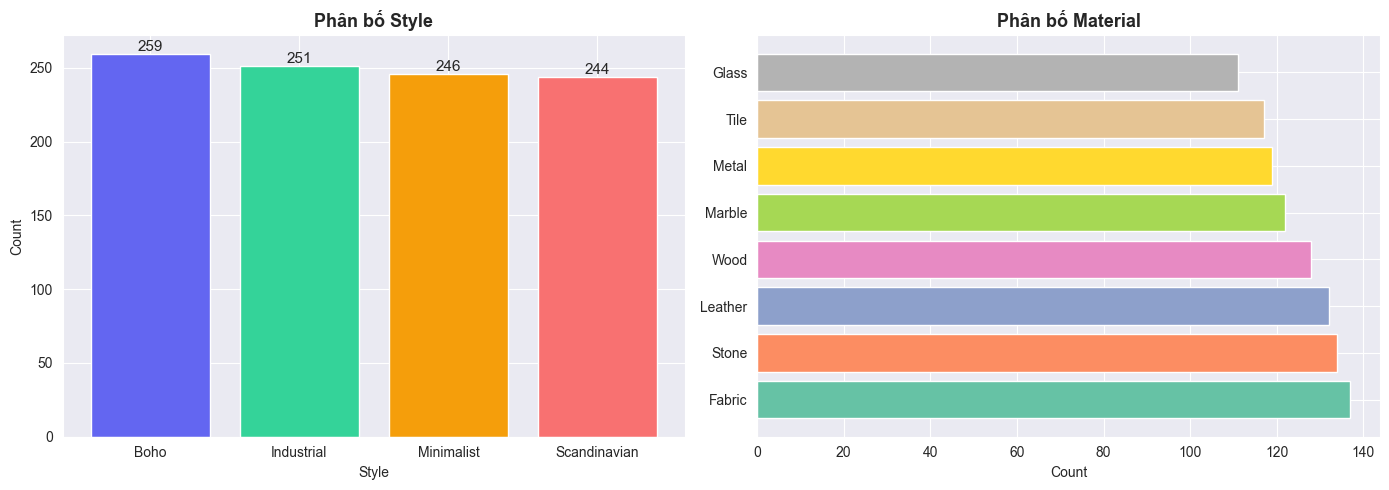

Tổng: 1000 mẫu | 4 styles | 8 materials


In [4]:
# ── EDA: Biểu đồ phân bố ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Style
style_cnt = df["style_label"].value_counts()
axes[0].bar(style_cnt.index, style_cnt.values,
            color=["#6366f1","#34d399","#f59e0b","#f87171"])
axes[0].set_title("Phân bố Style", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Style"); axes[0].set_ylabel("Count")
for i, v in enumerate(style_cnt.values):
    axes[0].text(i, v + 2, str(v), ha="center", fontsize=11)

# Material
mat_cnt = df["material_label"].value_counts()
colors_m = plt.cm.Set2(np.linspace(0, 1, len(mat_cnt)))
axes[1].barh(mat_cnt.index, mat_cnt.values, color=colors_m)
axes[1].set_title("Phân bố Material", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Count")

plt.tight_layout()
plt.show()
print(f"Tổng: {len(df)} mẫu | {df['style_label'].nunique()} styles | {df['material_label'].nunique()} materials")

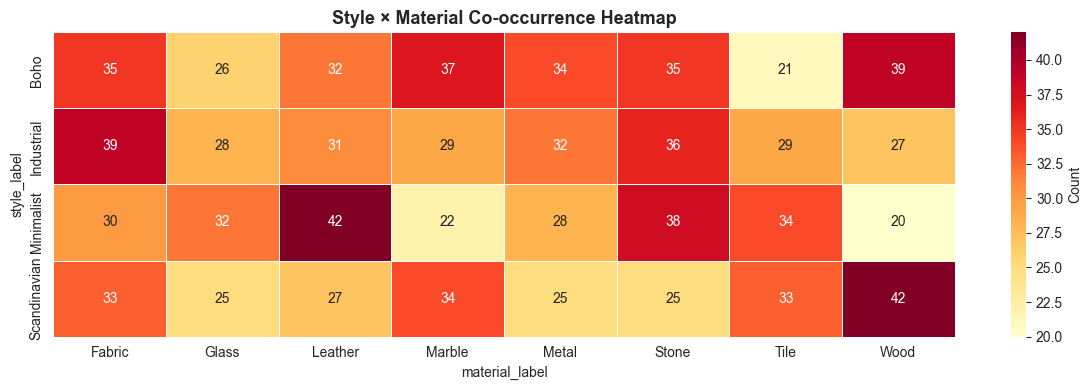

In [5]:
# ── EDA: Style × Material Heatmap ────────────────────────────────────────────
cross = pd.crosstab(df["style_label"], df["material_label"])
plt.figure(figsize=(12, 4))
sns.heatmap(cross, annot=True, fmt="d", cmap="YlOrRd",
            linewidths=0.5, cbar_kws={"label": "Count"})
plt.title("Style × Material Co-occurrence Heatmap", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

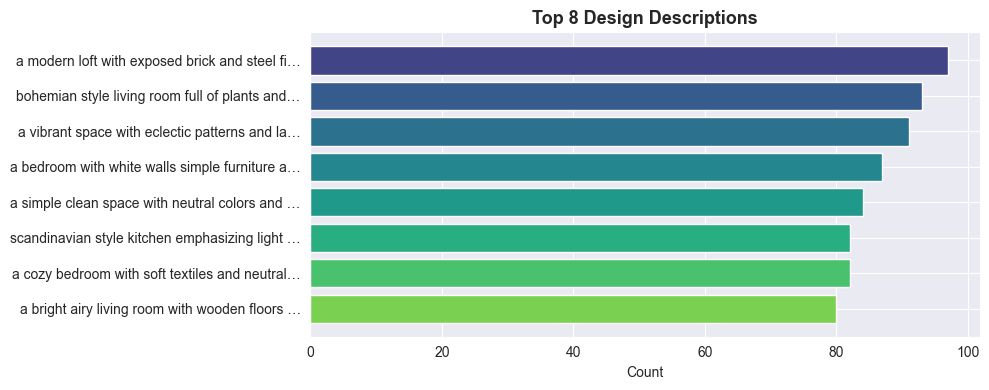

In [6]:
# ── EDA: Phân bố mô tả ───────────────────────────────────────────────────────
desc_cnt = df["clean_design_description"].value_counts().head(8)
labels = [d[:45]+"…" if len(d) > 45 else d for d in desc_cnt.index]
plt.figure(figsize=(10, 4))
plt.barh(labels, desc_cnt.values, color=plt.cm.viridis(np.linspace(0.2, 0.8, 8)))
plt.title("Top 8 Design Descriptions", fontsize=13, fontweight="bold")
plt.xlabel("Count")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 3. Tiền xử lý dữ liệu

> ✅ **Giữ nguyên code gốc từ notebook nhóm** – chỉ bổ sung phần chuẩn bị features cho ML models.

In [7]:
# ── CODE GỐC NHÓM: clean_text ────────────────────────────────────────────────
def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

# Verify: áp dụng lại trên df (đã có trong dataset_cleaned_ready.csv)
# df["clean_design_description"] = df["design_description"].apply(clean_text)
print("✓ clean_text function sẵn sàng")
print("Sample:", clean_text("Gian bếp tối giản bằng gỗ!"))

✓ clean_text function sẵn sàng
Sample: gian bếp tối giản bằng gỗ


In [8]:
# ── Chuẩn bị feature matrix & target vectors ─────────────────────────────────

def hex_to_rgb(hex_str: str) -> tuple:
    """Chuyển '#RRGGBB' → (R, G, B) int. Trả (128,128,128) nếu lỗi."""
    try:
        h = str(hex_str).strip().lstrip("#")
        return tuple(int(h[i:i+2], 16) for i in (0, 2, 4))
    except Exception:
        return (128, 128, 128)

# Feature X: 12 chiều (4 style + 8 material) one-hot
FEATURE_COLS = STYLE_COLS + MATERIAL_COLS
X = df[FEATURE_COLS].fillna(0).values

# Target y_style: tên nhãn style
y_style_idx = df[STYLE_COLS].fillna(0).values.argmax(axis=1)
y_style     = [STYLE_NAMES[i] for i in y_style_idx]

# Target y_material: tên nhãn material
y_mat_idx   = df[MATERIAL_COLS].fillna(0).values.argmax(axis=1)
y_material  = [MATERIAL_NAMES[i] for i in y_mat_idx]

# Target y_color: 9 chiều RGB (R1,G1,B1, R2,G2,B2, R3,G3,B3)
rgb_matrix = []
for _, row in df.iterrows():
    r1,g1,b1 = hex_to_rgb(row["color1"])
    r2,g2,b2 = hex_to_rgb(row["color2"])
    r3,g3,b3 = hex_to_rgb(row["color3"])
    rgb_matrix.append([r1,g1,b1, r2,g2,b2, r3,g3,b3])
y_color = np.array(rgb_matrix, dtype=float)

print(f"X shape:        {X.shape}        (features)")
print(f"y_style:        {len(y_style)} labels   → {set(y_style)}")
print(f"y_material:     {len(y_material)} labels → {set(y_material)}")
print(f"y_color shape:  {y_color.shape}  (9 RGB targets)")

X shape:        (1000, 12)        (features)
y_style:        1000 labels   → {'Minimalist', 'Scandinavian', 'Boho', 'Industrial'}
y_material:     1000 labels → {'Metal', 'Tile', 'Wood', 'Glass', 'Fabric', 'Marble', 'Stone', 'Leather'}
y_color shape:  (1000, 9)  (9 RGB targets)


## 4. Mô hình phân loại Style (RandomForest Classifier)

In [9]:
# ── Train / Test split ────────────────────────────────────────────────────────
X_tr_s, X_te_s, y_tr_s, y_te_s = train_test_split(
    X, y_style, test_size=0.2, random_state=42, stratify=y_style)

print(f"Train: {X_tr_s.shape[0]}  |  Test: {X_te_s.shape[0]}")

Train: 800  |  Test: 200


In [10]:
# ── Huấn luyện ───────────────────────────────────────────────────────────────
style_clf = RandomForestClassifier(
    n_estimators=200, max_depth=8, random_state=42, n_jobs=-1)
style_clf.fit(X_tr_s, y_tr_s)

y_pred_s = style_clf.predict(X_te_s)
acc_s    = accuracy_score(y_te_s, y_pred_s)
print(f"Style Classifier Accuracy: {acc_s:.4f}")
print()
print(classification_report(y_te_s, y_pred_s))

Style Classifier Accuracy: 1.0000

              precision    recall  f1-score   support

        Boho       1.00      1.00      1.00        52
  Industrial       1.00      1.00      1.00        50
  Minimalist       1.00      1.00      1.00        49
Scandinavian       1.00      1.00      1.00        49

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



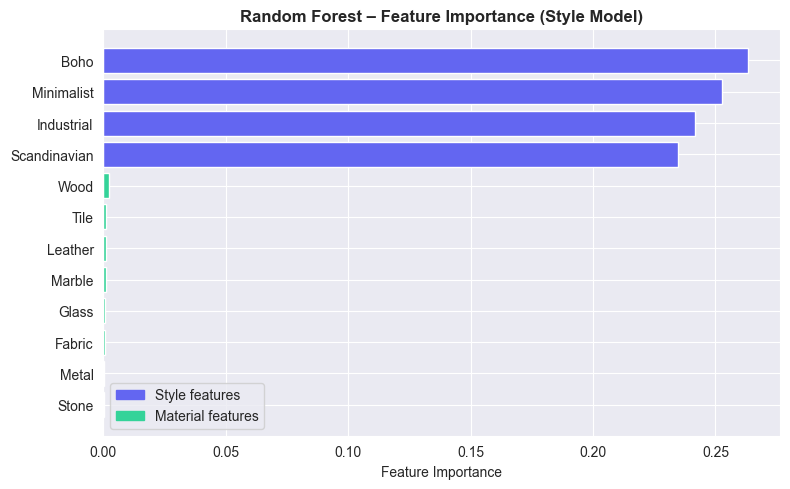

In [11]:
# ── Feature Importance: Style model ──────────────────────────────────────────
feat_names = STYLE_NAMES + MATERIAL_NAMES   # 12 features
importances = style_clf.feature_importances_
order = np.argsort(importances)

plt.figure(figsize=(8, 5))
colors = ["#6366f1" if i < 4 else "#34d399" for i in order]
plt.barh([feat_names[i] for i in order], importances[order], color=colors)
plt.xlabel("Feature Importance")
plt.title("Random Forest – Feature Importance (Style Model)", fontweight="bold")
legend_elems = [mpatches.Patch(color="#6366f1", label="Style features"),
                mpatches.Patch(color="#34d399", label="Material features")]
plt.legend(handles=legend_elems)
plt.tight_layout()
plt.show()

## 5. Mô hình phân loại Material (RandomForest Classifier)

In [12]:
X_tr_m, X_te_m, y_tr_m, y_te_m = train_test_split(
    X, y_material, test_size=0.2, random_state=42, stratify=y_material)

material_clf = RandomForestClassifier(
    n_estimators=200, max_depth=8, random_state=42, n_jobs=-1)
material_clf.fit(X_tr_m, y_tr_m)

y_pred_m = material_clf.predict(X_te_m)
acc_m    = accuracy_score(y_te_m, y_pred_m)
print(f"Material Classifier Accuracy: {acc_m:.4f}")
print()
print(classification_report(y_te_m, y_pred_m))

Material Classifier Accuracy: 1.0000

              precision    recall  f1-score   support

      Fabric       1.00      1.00      1.00        27
       Glass       1.00      1.00      1.00        22
     Leather       1.00      1.00      1.00        26
      Marble       1.00      1.00      1.00        25
       Metal       1.00      1.00      1.00        24
       Stone       1.00      1.00      1.00        27
        Tile       1.00      1.00      1.00        23
        Wood       1.00      1.00      1.00        26

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



## 6. Mô hình hồi quy màu sắc (MultiOutput RandomForest Regressor)

Dự đoán 9 giá trị (R,G,B) × 3 màu từ feature vector. Dataset dùng màu ngẫu nhiên nên R² thấp — đây là giới hạn dữ liệu, không phải lỗi mô hình.

In [13]:
X_tr_c, X_te_c, y_tr_c, y_te_c = train_test_split(
    X, y_color, test_size=0.2, random_state=42)

color_reg = MultiOutputRegressor(
    RandomForestRegressor(n_estimators=150, max_depth=8,
                          random_state=42, n_jobs=-1),
    n_jobs=-1)
color_reg.fit(X_tr_c, y_tr_c)

y_pred_c = color_reg.predict(X_te_c)
r2_c     = r2_score(y_te_c, y_pred_c)
print(f"Color Regressor R²: {r2_c:.4f}")
print("(Ghi chú: màu trong dataset là random hex → R² thấp là bình thường)")

Color Regressor R²: -0.0518
(Ghi chú: màu trong dataset là random hex → R² thấp là bình thường)


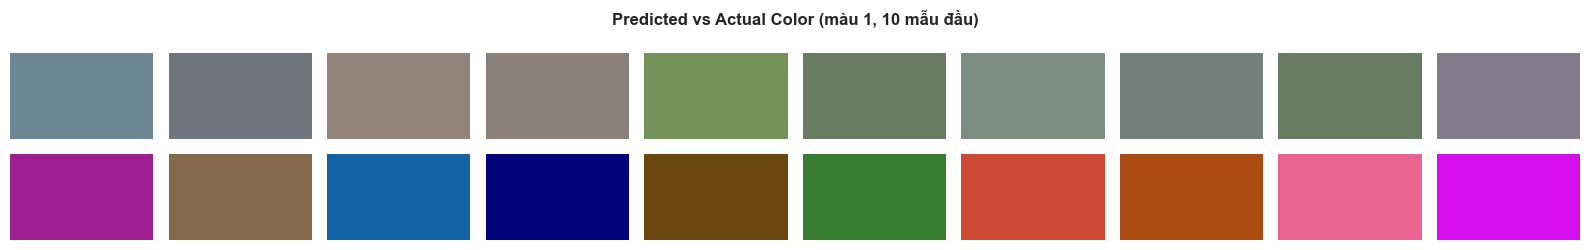

In [14]:
# ── Visualize predicted vs actual colors (10 mẫu đầu) ─────────────────────
n_show = 10
pred_clipped = np.clip(y_pred_c[:n_show], 0, 255).astype(int)
actual        = y_te_c[:n_show].astype(int)

fig, axes = plt.subplots(2, n_show, figsize=(16, 2.5))
for i in range(n_show):
    # Predicted
    rgb_p = tuple(int(v) for v in pred_clipped[i, 0:3])
    axes[0, i].add_patch(plt.Rectangle((0,0),1,1,
        color=[v/255 for v in rgb_p]))
    axes[0, i].set_xlim(0,1); axes[0, i].set_ylim(0,1)
    axes[0, i].axis("off")
    if i == 0: axes[0, i].set_ylabel("Pred", fontsize=9)

    # Actual
    rgb_a = tuple(int(v) for v in actual[i, 0:3])
    axes[1, i].add_patch(plt.Rectangle((0,0),1,1,
        color=[v/255 for v in rgb_a]))
    axes[1, i].set_xlim(0,1); axes[1, i].set_ylim(0,1)
    axes[1, i].axis("off")
    if i == 0: axes[1, i].set_ylabel("Actual", fontsize=9)

fig.suptitle("Predicted vs Actual Color (màu 1, 10 mẫu đầu)", fontweight="bold")
plt.tight_layout()
plt.show()

## 7. NLP Embedding – SentenceTransformer

Dùng `all-MiniLM-L6-v2` để chuyển câu mô tả → vector 384 chiều.  
Embedding được cache vào `description_embeddings.pkl` để tránh encode lại.

In [15]:
from sentence_transformers import SentenceTransformer

print("Loading SentenceTransformer all-MiniLM-L6-v2 …")
st_model = SentenceTransformer("all-MiniLM-L6-v2")
print("✓ Model loaded")

def encode_query(text: str) -> np.ndarray:
    """Chuyển câu mô tả → vector (1, 384) đã normalize."""
    return st_model.encode([text], normalize_embeddings=True)

# Test
sample_emb = encode_query("Gian bếp tối giản bằng gỗ")
print(f"Query embedding shape: {sample_emb.shape}")
print(f"First 5 dims: {sample_emb[0, :5]}")

Loading SentenceTransformer all-MiniLM-L6-v2 …


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 4082.84it/s]


✓ Model loaded
Query embedding shape: (1, 384)
First 5 dims: [-0.06661138  0.05021159  0.01224139  0.05253709 -0.09859783]


In [16]:
# ── Encode toàn bộ dataset (cache vào file) ──────────────────────────────────
EMB_PATH = "description_embeddings.pkl"

if os.path.exists(EMB_PATH):
    dataset_embeddings = joblib.load(EMB_PATH)
    print(f"✓ Loaded embeddings from cache: {dataset_embeddings.shape}")
else:
    print(f"Encoding {len(df)} descriptions …")
    texts = df["clean_design_description"].fillna("").tolist()
    dataset_embeddings = st_model.encode(
        texts, normalize_embeddings=True,
        show_progress_bar=True, batch_size=64)
    joblib.dump(dataset_embeddings, EMB_PATH)
    print(f"✓ Saved embeddings: {dataset_embeddings.shape}")

✓ Loaded embeddings from cache: (1000, 384)


## 8. Cosine Similarity Search

In [17]:
def recommend(query: str, top_n: int = 3,
              style_filter: str = None, material_filter: str = None) -> pd.DataFrame:
    """
    Pipeline gợi ý hoàn chỉnh:
      1. Encode query
      2. Filter theo style / material (nếu có)
      3. Cosine similarity → Top-N
    """
    # Encode query
    q_emb = encode_query(query)   # (1, 384)

    # Filter
    mask = pd.Series([True] * len(df))
    if style_filter:
        mask &= (df["style_label"].str.lower() == style_filter.lower())
    if material_filter:
        mask &= (df["material_label"].str.lower() == material_filter.lower())

    filtered    = df[mask].copy()
    filt_embs   = dataset_embeddings[filtered.index]   # (M, 384)

    # Fallback nếu filter quá chặt
    if len(filtered) < top_n:
        filtered  = df.copy()
        filt_embs = dataset_embeddings

    # Cosine similarity
    sims = cosine_similarity(q_emb, filt_embs)[0]      # (M,)
    filtered["similarity"] = sims
    top = filtered.nlargest(top_n, "similarity").reset_index(drop=True)
    return top[["Image_id", "style_label", "material_label",
                "color1", "color2", "color3",
                "similarity", "clean_design_description"]]


# ── Test nhanh ───────────────────────────────────────────────────────────────
test_result = recommend("a simple clean space with wooden furniture", top_n=3)
print("Top 3 kết quả:")
display(test_result)

Top 3 kết quả:


,Image_id,style_label,material_label,color1,color2,color3,similarity,clean_design_description
0,17,Scandinavian,Marble,#C0B4E1,#ABDDC3,#E47586,0.633019,a bright airy living room with wooden floors a...
1,19,Scandinavian,Tile,#E25DAD,#98CEC6,#F7CAF5,0.633019,a bright airy living room with wooden floors a...
2,35,Scandinavian,Wood,#30D8D6,#8AD080,#29A5C7,0.633019,a bright airy living room with wooden floors a...


## 9. Helper Functions & Demo đầy đủ

In [18]:
# ── Keyword → feature vector (dùng cho ML models) ────────────────────────────
STYLE_KEYWORDS = {
    "Boho":         ["boho","bohemian","handmade","eclectic","plant",
                     "colorful","artistic","ethnic","textile"],
    "Industrial":   ["industrial","loft","brick","steel","metal",
                     "exposed","concrete","urban","modern"],
    "Minimalist":   ["minimalist","minimal","simple","clean","neutral",
                     "open","white","tối giản","đơn giản"],
    "Scandinavian": ["scandinavian","nordic","cozy","hygge","light",
                     "wood","functional","natural","warm"],
}
MATERIAL_KEYWORDS = {
    "Fabric":  ["fabric","textile","linen","cotton","velvet","vải"],
    "Glass":   ["glass","mirror","transparent","kính"],
    "Leather": ["leather","da","suede"],
    "Marble":  ["marble","đá hoa cương","cẩm thạch"],
    "Metal":   ["metal","steel","iron","brass","kim loại","thép"],
    "Stone":   ["stone","concrete","đá","bê tông"],
    "Tile":    ["tile","ceramic","gạch","mosaic"],
    "Wood":    ["wood","wooden","timber","oak","gỗ"],
}

def _keyword_scores(text: str, keyword_map: dict) -> np.ndarray:
    text_lower = text.lower()
    scores = np.array([sum(1 for kw in kws if kw in text_lower)
                       for kws in keyword_map.values()], dtype=float)
    total = scores.sum()
    return scores / total if total > 0 else np.ones(len(scores)) / len(scores)

def build_feature_vector(query: str) -> np.ndarray:
    """Query text → (1, 12) feature vector cho ML models."""
    sv = _keyword_scores(query, STYLE_KEYWORDS)      # (4,)
    mv = _keyword_scores(query, MATERIAL_KEYWORDS)   # (8,)
    return np.concatenate([sv, mv]).reshape(1, -1)

def rgb_to_hex(r, g, b) -> str:
    return "#{:02X}{:02X}{:02X}".format(int(r), int(g), int(b))

def get_palette_description(rgbs: list) -> str:
    def name(r, g, b):
        if max(r,g,b)-min(r,g,b) < 30:
            br = r*0.299 + g*0.587 + b*0.114
            return "Light Neutral" if br>200 else "Mid Neutral" if br>100 else "Dark Neutral"
        if r>g and r>b:   return "Warm Red/Orange"
        if g>r and g>b:   return "Cool Green"
        if b>r and b>g:   return "Cool Blue/Purple"
        return "Mixed"
    names = [name(*c) for c in rgbs]
    if sum("Warm" in n for n in names) >= 2:   return "Warm Tones Palette"
    if sum("Cool" in n for n in names) >= 2:   return "Cool Tones Palette"
    if sum("Neutral" in n for n in names) >= 2: return "Neutral / Earthy Palette"
    return "Eclectic Mixed Palette"

print("✓ Helper functions sẵn sàng")

✓ Helper functions sẵn sàng


In [19]:
# ── DEMO ĐẦY ĐỦ ──────────────────────────────────────────────────────────────
DEMO_QUERIES = [
    "Gian bếp tối giản bằng gỗ",
    "Phòng khách công nghiệp với kim loại và bê tông",
    "Không gian Scandinavian ấm cúng tự nhiên",
    "Phòng ngủ Boho đầy cây và vải thủ công",
]

for query in DEMO_QUERIES:
    print("═" * 60)
    print(f"Query: {query}")

    X_q           = build_feature_vector(query)
    style_pred    = style_clf.predict(X_q)[0]
    material_pred = material_clf.predict(X_q)[0]
    color_raw     = np.clip(color_reg.predict(X_q)[0], 0, 255).astype(int)
    color_rgbs    = [(color_raw[0],color_raw[1],color_raw[2]),
                     (color_raw[3],color_raw[4],color_raw[5]),
                     (color_raw[6],color_raw[7],color_raw[8])]
    palette       = get_palette_description(color_rgbs)
    hex_colors    = [rgb_to_hex(*c) for c in color_rgbs]

    print(f"  Style    : {style_pred}")
    print(f"  Material : {material_pred}")
    print(f"  Palette  : {palette}  {hex_colors}")

    top3 = recommend(query, top_n=3,
                     style_filter=style_pred, material_filter=material_pred)
    for _, row in top3.iterrows():
        sim_pct = row["similarity"] * 100
        print(f"  [{sim_pct:5.1f}%] #{int(row['Image_id'])} "
              f"{row['style_label']}/{row['material_label']} "
              f"– {row['clean_design_description'][:50]}…")
    print()

════════════════════════════════════════════════════════════
Query: Gian bếp tối giản bằng gỗ
  Style    : Minimalist
  Material : Wood
  Palette  : Cool Tones Palette  ['#968E6D', '#7F7CA2', '#839F74']
  [  8.1%] #116 Minimalist/Wood – a bedroom with white walls simple furniture and na…
  [  8.1%] #212 Minimalist/Wood – a bedroom with white walls simple furniture and na…
  [  8.1%] #311 Minimalist/Wood – a bedroom with white walls simple furniture and na…

════════════════════════════════════════════════════════════
Query: Phòng khách công nghiệp với kim loại và bê tông
  Style    : Scandinavian
  Material : Glass
  Palette  : Neutral / Earthy Palette  ['#7E817E', '#797F7B', '#7F7E7F']
  [  9.5%] #7 Scandinavian/Glass – scandinavian style kitchen emphasizing light and f…
  [  9.5%] #237 Scandinavian/Glass – scandinavian style kitchen emphasizing light and f…
  [  9.5%] #252 Scandinavian/Glass – scandinavian style kitchen emphasizing light and f…

══════════════════════════════════════

## 10. Visualizations & Dashboard (Plotly)

In [20]:
# ── Dashboard 4-panel ────────────────────────────────────────────────────────
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=("Phân bố Style", "Phân bố Material",
                    "Feature Importance (Style RF)", "Style × Material Heatmap"),
    specs=[[{"type":"bar"}, {"type":"bar"}],
           [{"type":"bar"}, {"type":"heatmap"}]]
)

# Panel 1: Style distribution
sc = df["style_label"].value_counts()
fig.add_trace(go.Bar(x=sc.index, y=sc.values,
                     marker_color=["#6366f1","#34d399","#f59e0b","#f87171"],
                     showlegend=False), row=1, col=1)

# Panel 2: Material distribution
mc = df["material_label"].value_counts()
fig.add_trace(go.Bar(x=mc.index, y=mc.values,
                     marker_color="#60a5fa", showlegend=False), row=1, col=2)

# Panel 3: Feature importance
feat_names_all = STYLE_NAMES + MATERIAL_NAMES
fi = style_clf.feature_importances_
order = np.argsort(fi)
fig.add_trace(go.Bar(y=[feat_names_all[i] for i in order],
                     x=fi[order], orientation="h",
                     marker_color="#a78bfa", showlegend=False), row=2, col=1)

# Panel 4: Heatmap
cross = pd.crosstab(df["style_label"], df["material_label"])
fig.add_trace(go.Heatmap(z=cross.values,
                          x=cross.columns.tolist(),
                          y=cross.index.tolist(),
                          colorscale="Blues",
                          showscale=True,
                          text=cross.values,
                          texttemplate="%{text}"), row=2, col=2)

fig.update_layout(height=750, title_text="📊 ML Design System – Dashboard",
                  title_font_size=16)
fig.show()

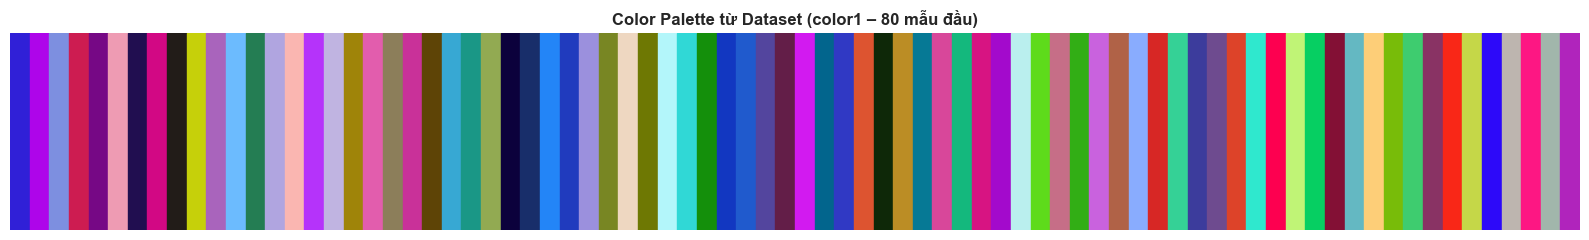

In [21]:
# ── Color palette visualization từ dataset ────────────────────────────────────
valid_hex = df["color1"].dropna().head(80).str.strip()
valid_hex = [c for c in valid_hex if re.match(r'^#[0-9A-Fa-f]{6}$', c)]

fig2, ax = plt.subplots(figsize=(16, 2.5))
ax.set_xlim(0, len(valid_hex)); ax.set_ylim(0, 1)
for i, hex_c in enumerate(valid_hex):
    rgb = tuple(int(hex_c.lstrip("#")[j:j+2], 16)/255 for j in (0,2,4))
    ax.add_patch(plt.Rectangle((i, 0), 1, 1, color=rgb))
ax.axis("off")
ax.set_title("Color Palette từ Dataset (color1 – 80 mẫu đầu)", fontweight="bold")
plt.tight_layout()
plt.show()

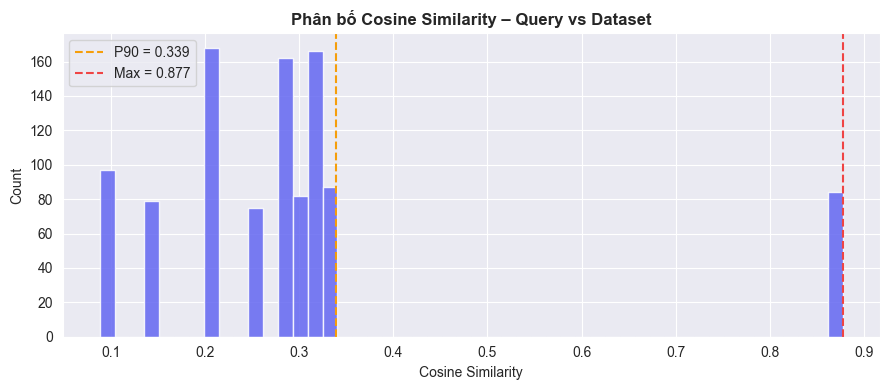

In [22]:
# ── Similarity score distribution ────────────────────────────────────────────
q_emb_viz   = encode_query("simple clean space neutral colors open areas")
sims_all    = cosine_similarity(q_emb_viz, dataset_embeddings)[0]

plt.figure(figsize=(9, 4))
plt.hist(sims_all, bins=50, color="#6366f1", edgecolor="white", alpha=0.85)
plt.axvline(np.percentile(sims_all, 90), color="#f59e0b", linestyle="--",
            label=f"P90 = {np.percentile(sims_all,90):.3f}")
plt.axvline(sims_all.max(), color="#ef4444", linestyle="--",
            label=f"Max = {sims_all.max():.3f}")
plt.xlabel("Cosine Similarity"); plt.ylabel("Count")
plt.title("Phân bố Cosine Similarity – Query vs Dataset", fontweight="bold")
plt.legend(); plt.tight_layout(); plt.show()

## 11. Lưu Models & Artifacts

In [23]:
os.makedirs("models", exist_ok=True)

joblib.dump(style_clf,    "models/style_model.pkl")
joblib.dump(material_clf, "models/material_model.pkl")
joblib.dump(color_reg,    "models/color_model.pkl")
joblib.dump({
    "style_names":    STYLE_NAMES,
    "material_names": MATERIAL_NAMES,
    "style_cols":     STYLE_COLS,
    "material_cols":  MATERIAL_COLS,
    "feature_cols":   FEATURE_COLS,
}, "models/metadata.pkl")

print("✓ Đã lưu:")
for f in os.listdir("models"):
    sz = os.path.getsize(f"models/{f}") / 1024
    print(f"  models/{f}  ({sz:.1f} KB)")

print()
print("✓ Embeddings:", "description_embeddings.pkl" if os.path.exists("description_embeddings.pkl") else "chưa tạo")

✓ Đã lưu:
  models/color_model.pkl  (5447.6 KB)
  models/material_model.pkl  (673.4 KB)
  models/metadata.pkl  (0.5 KB)
  models/style_model.pkl  (412.7 KB)

✓ Embeddings: description_embeddings.pkl


---

## Tóm tắt pipeline

| Bước | Module | Mô tả |
|---|---|---|
| 1 | `build_feature_vector()` | Keyword matching → (1×12) feature vector |
| 2 | `style_clf` (RF) | Phân loại phong cách thiết kế (4 nhãn) |
| 3 | `material_clf` (RF) | Phân loại vật liệu (8 nhãn) |
| 4 | `color_reg` (MultiOutput RF) | Dự đoán 3 màu RGB |
| 5 | `SentenceTransformer` | Encode query → vector 384d |
| 6 | `cosine_similarity()` | Tìm Top-N mẫu tương đồng nhất |

### Giá trị học thuật
- End-to-end ML pipeline: NLP + Classification + Regression + Similarity Search
- Kết hợp supervised learning (RF) với semantic search (Sentence-BERT)
- MultiOutput regression cho bài toán dự đoán đa mục tiêu
- Hybrid filtering: ML prediction filter → vector similarity ranking
